In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

In [14]:
#load dataset
housing= fetch_california_housing()

#createe dataframe
data=pd.DataFrame(housing.data,columns=housing.feature_names)

#add target columns
data["Price"]=housing.target

# print(housing.keys())
#print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [15]:
#select one feature
X=data[['AveRooms']].values
Y=data['Price'].values



In [16]:
#split data

X_train,X_test,y_train,y_test=train_test_split(X,Y,
                                               test_size=0.2,
                                               random_state=42)

In [17]:
#feature scaling

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [62]:
w=0
b=0
learning_rate=0.01
epochs=1000

n=len(X_train_scaled)
cost_history=[]
for i in range(epochs):
    y_pred=w*X_train_scaled.flatten() +b
    dw=(1/n)* np.sum((y_pred -y_train) *X_train_scaled.flatten())             
    db=(1/n)* np.sum((y_pred -y_train))
    w=w-learning_rate* dw
    b=b-learning_rate* db
    if i%100==0:
        cost=(1/(2*n)) * np.sum((y_pred- y_train)**2)
        cost_history.append(cost)
        print(f"epoch {i},cost={cost:.4f}")
y_pred_gd = w * X_test_scaled.flatten() +b

epoch 0,cost=2.8149
epoch 100,cost=0.9414
epoch 200,cost=0.6904
epoch 300,cost=0.6568
epoch 400,cost=0.6523
epoch 500,cost=0.6517
epoch 600,cost=0.6516
epoch 700,cost=0.6516
epoch 800,cost=0.6516
epoch 900,cost=0.6516


In [63]:
print("Gradient Descent")
print("..................")
print("weight",w)
print("bias",b)
print("MSE",mean_squared_error(y_test,y_pred_gd))
print("R2 score",r2_score(y_test,y_pred_gd))




Gradient Descent
..................
weight 0.18323090648660517
bias 2.0718574888450205
MSE 1.292327655590046
R2 score 0.013798228607320828


In [64]:
#Normal Equation
#...............

X_train_ne=np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne=np.c_[np.ones((len(X_test),1)),X_test]

theta=np.linalg.inv(X_train_ne.T@X_train_ne)@X_train_ne.T@y_train

y_pred_ne=X_test_ne @theta

print("Normal Equation")
print("..................")
print("intercept",theta[0])
print("slope",theta[1])
print("MSE",mean_squared_error(y_test,y_pred_ne))
print("R2score",r2_score(y_test,y_pred_ne))


Normal Equation
..................
intercept 1.6547622685968417
slope 0.07675558963126736
MSE 1.2923314440807299
R2score 0.013795337532284901


In [65]:
# sort values for smooth regression lines

sort_axis=np.argsort(X_test.flatten())
x_sorted=X_test[sort_axis]
y_pred_ne_sorted=y_pred_ne[sort_axis]

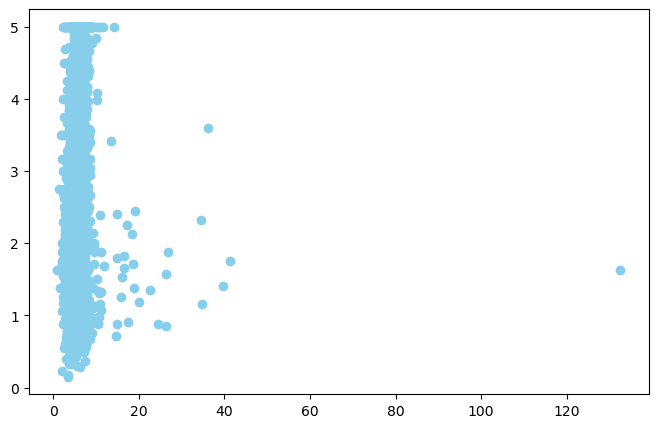

In [66]:
#regression lines visualisation

#sort X values for smooth line

index=np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
#scatter plot
plt.scatter(X_test,y_test,color='skyblue',label='Actual Data')

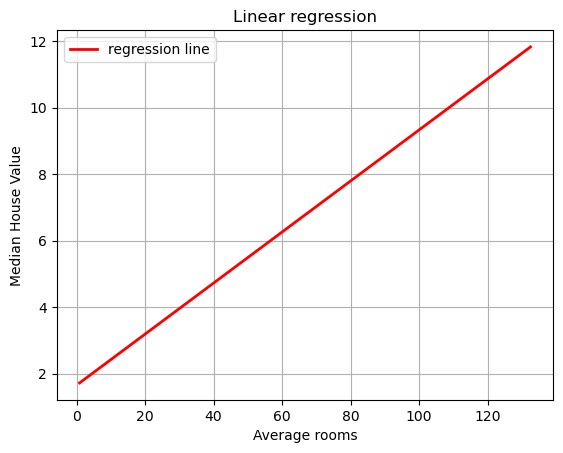

In [67]:
#regression line

plt.plot(
    X_test.flatten()[index],
    y_pred_ne[index],
    color="red",
    linewidth=2,
    label='regression line')

plt.title("Linear regression")
plt.xlabel("Average rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

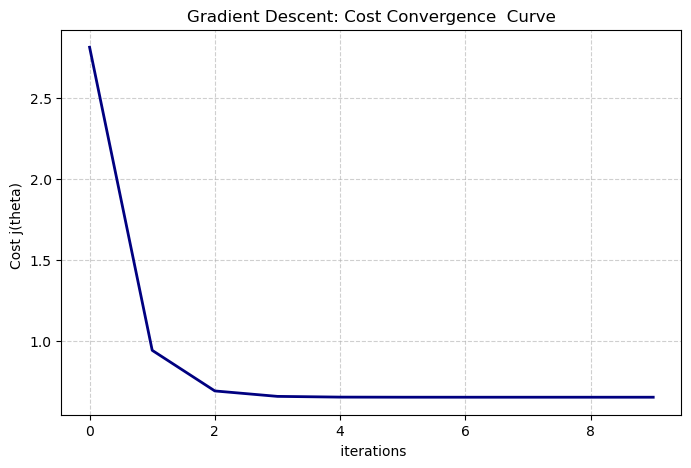

In [68]:
#cost convergence graph
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title('Gradient Descent: Cost Convergence  Curve')
plt.xlabel(" iterations")
plt.ylabel("Cost j(theta) ")
plt.grid(True,linestyle='--',alpha=0.6)

